In [1]:
#check directory
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display

# Kaggle input root
DATASET_ROOT = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Exists: {DATASET_ROOT.exists()}")

Dataset root: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Exists: True


In [2]:
#check tree
EXPECTED_SPLITS = ["train", "val", "test"]
EXPECTED_CLASSES = ["NORMAL", "PNEUMONIA"]

print("Dataset structure validation\n")

for split in EXPECTED_SPLITS:
    split_dir = DATASET_ROOT / split

    print(f"{split}/")
    
    if not split_dir.exists():
        print("  ❌ Missing split directory")
        continue

    for class_name in EXPECTED_CLASSES:
        class_dir = split_dir / class_name

        if class_dir.exists():
            print(f"  ├── {class_name}/ ✅")
        else:
            print(f"  ├── {class_name}/ ❌")

Dataset structure validation

train/
  ├── NORMAL/ ✅
  ├── PNEUMONIA/ ✅
val/
  ├── NORMAL/ ✅
  ├── PNEUMONIA/ ✅
test/
  ├── NORMAL/ ✅
  ├── PNEUMONIA/ ✅


In [3]:
IMAGE_EXTENSIONS = {".jpeg"}

records = []

for split in EXPECTED_SPLITS:
    for class_name in EXPECTED_CLASSES:
        class_dir = DATASET_ROOT / split / class_name

        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "split": split,
                    "label": class_name,
                    "path": str(path),
                    "filename": path.name,
                    "extension": path.suffix.lower(),
                })

manifest_df = pd.DataFrame(records)

print(f"Total image files: {len(manifest_df):,}")
display(manifest_df.head())

Total image files: 5,856


,split,label,path,filename,extension
0,train,NORMAL,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-0771-0001.jpeg,.jpeg
1,train,NORMAL,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-1294-0001-0002.jpeg,.jpeg
2,train,NORMAL,/kaggle/input/datasets/paultimothymooney/chest...,IM-0675-0001.jpeg,.jpeg
3,train,NORMAL,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-1169-0001.jpeg,.jpeg
4,train,NORMAL,/kaggle/input/datasets/paultimothymooney/chest...,IM-0421-0001.jpeg,.jpeg


In [4]:
#count photos and classify
print("Image extensions:")
display(manifest_df["extension"].value_counts())

print("\nImages by split:")
display(
    manifest_df["split"]
    .value_counts()
    .reindex(EXPECTED_SPLITS)
)

print("\nImages by split and class:")
class_distribution = pd.crosstab(
    manifest_df["split"],
    manifest_df["label"]
).reindex(
    index=EXPECTED_SPLITS,
    columns=EXPECTED_CLASSES,
    fill_value=0
)

display(class_distribution)

Image extensions:


extension
.jpeg    5856
Name: count, dtype: int64


Images by split:


split
train    5216
val        16
test      624
Name: count, dtype: int64


Images by split and class:


label,NORMAL,PNEUMONIA
split,,
train,1341,3875
val,8,8
test,234,390


In [5]:
#preprocessing - check readability of photos
from PIL import Image, UnidentifiedImageError

integrity_results = []

for row in manifest_df.itertuples(index=False):
    path = Path(row.path)

    result = {
        "split": row.split,
        "label": row.label,
        "path": row.path,
        "filename": row.filename,
        "valid": False,
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
    }  #bổ sung đầy đủ thông tin cho 1 đơn vị ảnh

    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            result["valid"] = True
            result["width"], result["height"] = img.size
            result["mode"] = img.mode
            result["format"] = img.format

    except (UnidentifiedImageError, OSError, ValueError) as exc:
        result["error"] = str(exc)

    integrity_results.append(result)

integrity_df = pd.DataFrame(integrity_results)

print(f"Total files checked: {len(integrity_df):,}")
print(f"Valid images: {integrity_df['valid'].sum():,}")
print(f"Invalid images: {(~integrity_df['valid']).sum():,}")

Total files checked: 5,856
Valid images: 5,856
Invalid images: 0


In [6]:
from PIL import Image, UnidentifiedImageError

integrity_results = []

for row in manifest_df.itertuples(index=False):
    path = Path(row.path)

    result = {
        "split": row.split,
        "label": row.label,
        "path": row.path,
        "filename": row.filename,
        "valid": False,
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
    }

    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            result["valid"] = True
            result["width"], result["height"] = img.size
            result["mode"] = img.mode
            result["format"] = img.format

    except (UnidentifiedImageError, OSError, ValueError) as exc:
        result["error"] = str(exc)

    integrity_results.append(result)

integrity_df = pd.DataFrame(integrity_results)

print(f"Total files checked: {len(integrity_df):,}")
print(f"Valid images: {integrity_df['valid'].sum():,}")
print(f"Invalid images: {(~integrity_df['valid']).sum():,}")

Total files checked: 5,856
Valid images: 5,856
Invalid images: 0


In [7]:
valid_df = integrity_df[integrity_df["valid"]].copy()

print("Most common image sizes:")

size_counts = (
    valid_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(size_counts.head(20))

Most common image sizes:


,width,height,count
841,1008,704,7
1112,1072,648,7
1157,1080,728,6
752,992,608,6
750,992,592,6
1755,1216,872,6
800,1000,704,5
838,1008,680,5
1496,1160,736,5
1603,1184,792,5


In [8]:
#check ratio width and height
valid_df["aspect_ratio"] = (
    valid_df["width"] / valid_df["height"]
)

display(
    valid_df["aspect_ratio"].describe()
)

count    5856.000000
mean        1.442986
std         0.254356
min         0.835391
25%         1.261627
50%         1.415885
75%         1.585750
max         3.378788
Name: aspect_ratio, dtype: float64

In [9]:
#hàm show_image
import matplotlib.pyplot as plt

def show_images(df, title, n=10):
    sample_df = df.head(n)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row["path"]).convert("L")

        ax.imshow(image, cmap="gray")
        ax.set_title(
            f'{row["filename"][:20]}\n'
            f'{row["width"]}×{row["height"]}\n'
            f'AR={row["aspect_ratio"]:.2f}',
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

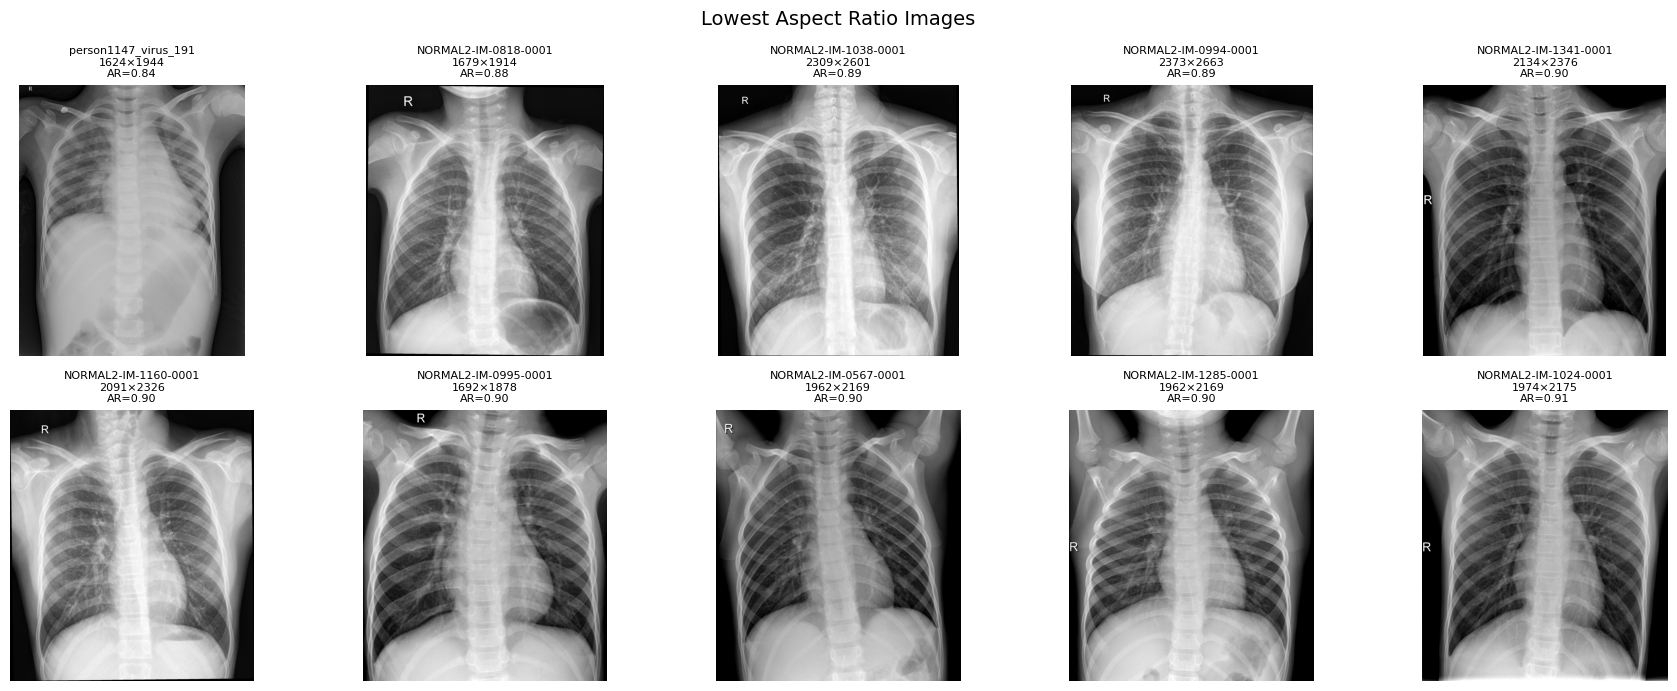

In [10]:
#show image lowest ratio
lowest_ar = (
    valid_df
    .sort_values("aspect_ratio", ascending=True)
)

show_images(
    lowest_ar,
    "Lowest Aspect Ratio Images"
)

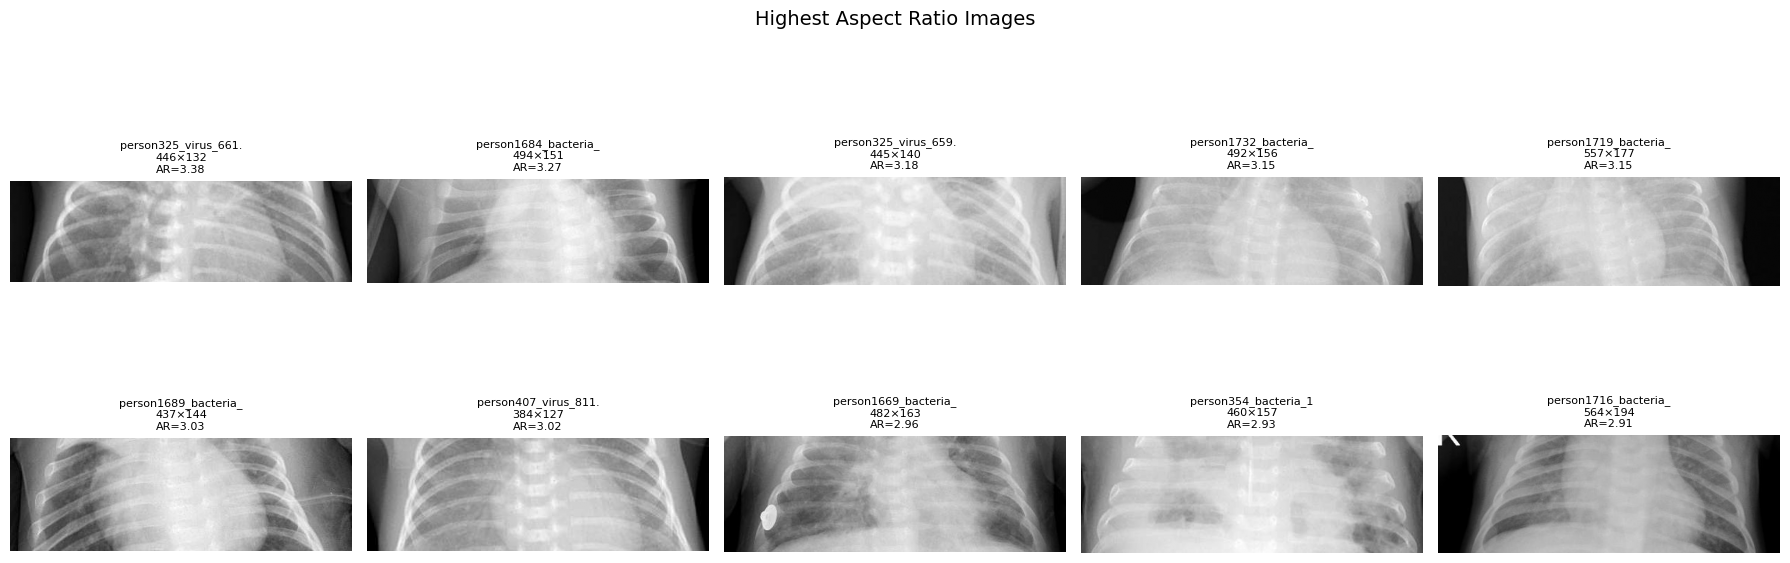

In [11]:
#show image highest ratio
highest_ar = (
    valid_df
    .sort_values("aspect_ratio", ascending=False)
)

show_images(
    highest_ar,
    "Highest Aspect Ratio Images"
)

Tổng số ảnh quét được: 5856

LỌC VỚI THRESHOLD > 1.9
Số lượng ảnh thỏa mãn: 321


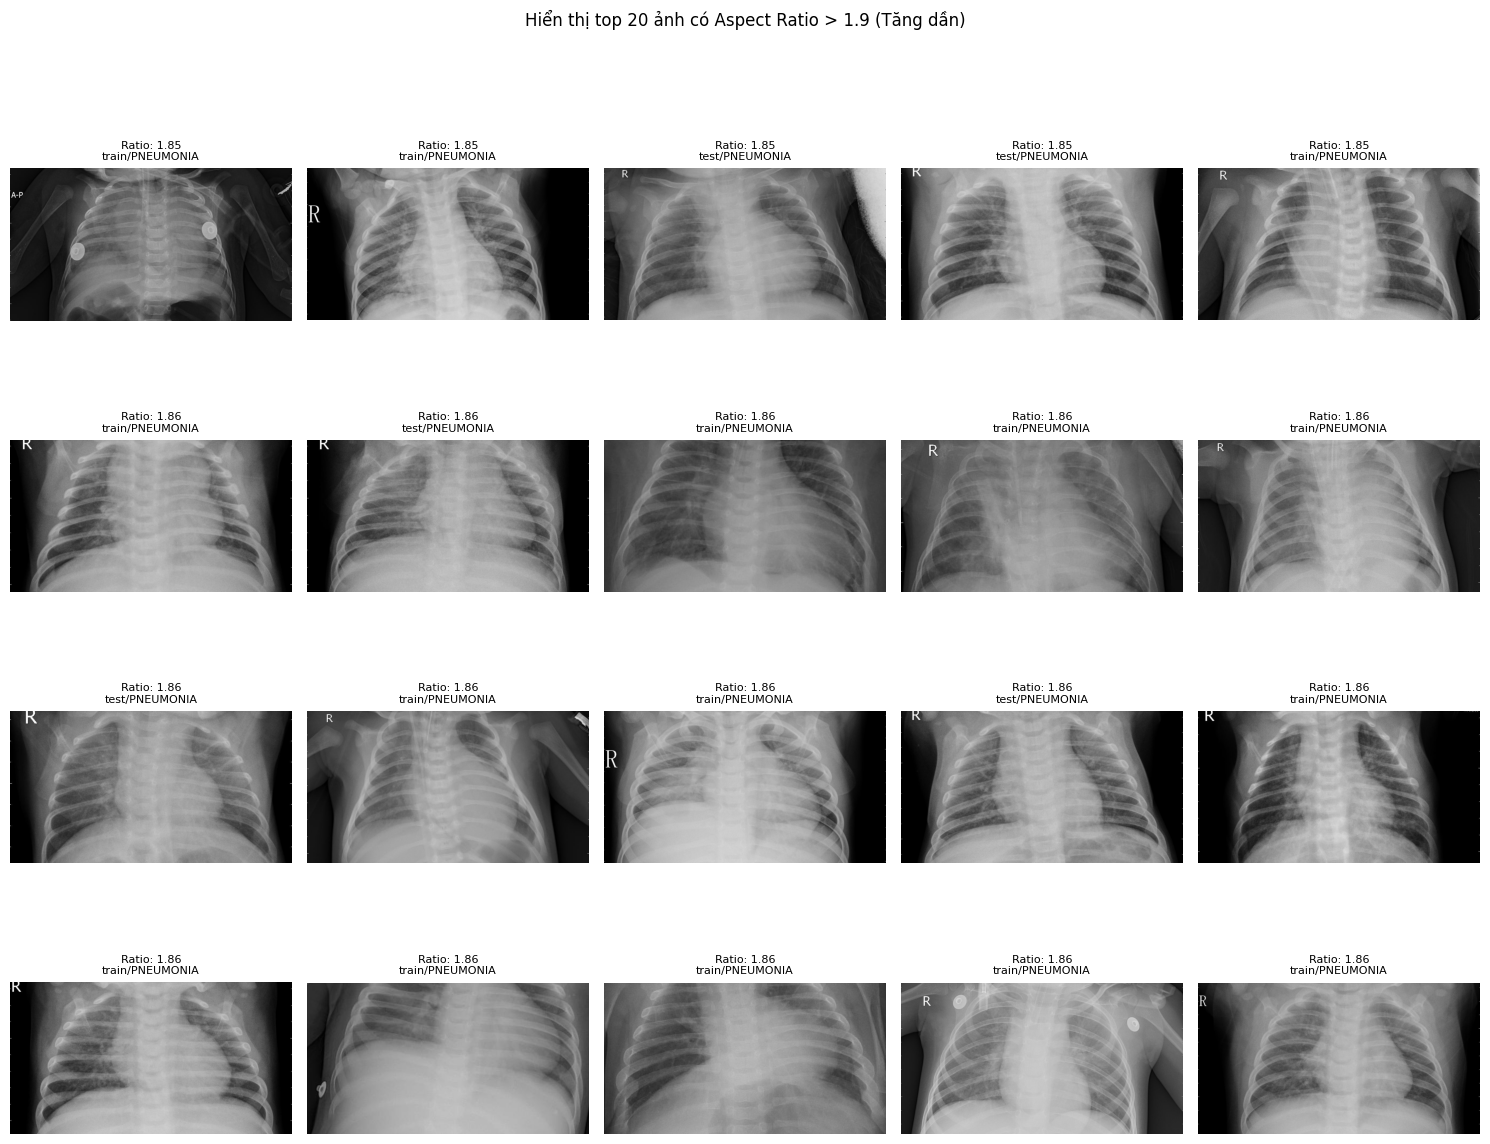

In [12]:
#ảnh theo threshold
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

%matplotlib inline

# Đường dẫn tới dataset trên Kaggle
BASE_PATH = Path(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
)


# Hàm quét toàn bộ ảnh
def get_image_info(base_path):
  data = []
  for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
      folder = base_path / split / label
      if folder.exists():
        for img_path in folder.glob("*.jpeg"):
          with Image.open(img_path) as img:
            w, h = img.size
          data.append({
              "path": str(img_path),
              "split": split,
              "label": label,
              "width": w,
              "height": h,
              "aspect_ratio": w / h,
          })
  return pd.DataFrame(data)


df = get_image_info(BASE_PATH)
print(f"Tổng số ảnh quét được: {len(df)}")

# Danh sách các ngưỡng tăng dần
thresholds = [1.85]

# Duyệt từng threshold theo thứ tự tăng dần
for th in sorted(thresholds):
  # Lọc ảnh và SẮP XẾP TĂNG DẦN theo aspect_ratio (ascending=True)
  filtered = df[df["aspect_ratio"] > th].sort_values(
      "aspect_ratio", ascending=True
  )

  print("\n" + "=" * 50)
  print(f"LỌC VỚI THRESHOLD > {th:.1f}")
  print(f"Số lượng ảnh thỏa mãn: {len(filtered)}")
  print("=" * 50)

  if len(filtered) == 0:
    print(f"Không có ảnh nào có aspect_ratio > {th:.1f}")
  else:
    # Hiển thị tối đa 20 ảnh tiêu biểu (lấy từ tỉ lệ nhỏ nhất đến lớn hơn)
    n = min(20, len(filtered))
    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, (idx, row) in enumerate(filtered.head(n).iterrows()):
      img = Image.open(row["path"]).convert("RGB")
      axes[i].imshow(img)
      axes[i].set_title(
          f"Ratio: {row['aspect_ratio']:.2f}\n{row['split']}/{row['label']}",
          fontsize=8,
      )
      axes[i].axis("off")

    # Ẩn các ô lưới thừa
    for j in range(i + 1, len(axes)):
      axes[j].axis("off")

    plt.suptitle(
        f"Hiển thị top {n} ảnh có Aspect Ratio > {th:.1f} (Tăng dần)",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

In [13]:
# Cell 1: Import và định nghĩa các hàm
!pip install imagehash -q

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import imagehash
import os
from collections import defaultdict

%matplotlib inline

# Hàm tính blur score (giữ nguyên)
def compute_blur_score(img_path, resize_size=(512, 512)):
    """
    Tính điểm sắc nét (blur score) của ảnh X-quang.
    Điểm càng cao = ảnh càng nét.
    Phương pháp:
      - Cắt vùng foreground (loại bỏ nền đen) bằng Otsu threshold + bounding box.
      - Resize về kích thước cố định để so sánh công bằng.
      - Áp dụng CLAHE để chuẩn hóa tương phản.
      - Tính Laplacian variance (biến thiên của Laplacian) và Tenengrad (biến thiên gradient).
      - Kết hợp có trọng số.
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan

    # Tạo mask foreground (pixel > 10 để loại nền đen)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Loại bỏ nhiễu nhỏ
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Tìm contour lớn nhất (vùng phổi)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.nan
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    # Crop vùng foreground với padding nhỏ
    pad = 5
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img.shape[1], x + w + pad)
    y2 = min(img.shape[0], y + h + pad)
    cropped = img[y1:y2, x1:x2]

    # Resize về kích thước cố định
    resized = cv2.resize(cropped, resize_size, interpolation=cv2.INTER_CUBIC)

    # CLAHE để chuẩn hóa tương phản
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(resized)

    # 1. Laplacian variance
    lap = cv2.Laplacian(enhanced, cv2.CV_64F)
    lap_var = lap.var()

    # 2. Tenengrad (gradient magnitude)
    gx = cv2.Sobel(enhanced, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(enhanced, cv2.CV_64F, 0, 1, ksize=3)
    tenengrad = (gx**2 + gy**2).mean()

    # Kết hợp điểm (log scale để tránh quá lớn)
    score = 0.6 * np.log10(lap_var + 1e-6) + 0.4 * np.log10(tenengrad + 1e-6)
    return score

def is_blurred(score, threshold):
    return score < threshold

def compute_aspect_ratio(img_path):
    with Image.open(img_path) as img:
        w, h = img.size
    return w / h

def compute_phash(img_path, hash_size=16):
    return str(imagehash.phash(Image.open(img_path), hash_size=hash_size))

def hamming_distance(hash1, hash2):
    """Tính khoảng cách Hamming giữa hai chuỗi hash (hex) dùng bit_count."""
    return (int(hash1, 16) ^ int(hash2, 16)).bit_count()

def find_duplicate_indices(df, hash_col='phash', split_col='split', distance_threshold = 86):
    """
    Tìm các ảnh có pHash gần giống nhau trong cùng split.
    Trả về danh sách index của các ảnh cần loại bỏ (giữ lại ảnh có blur_score cao hơn).
    """
    to_remove = set()
    # Nhóm theo split để tránh so sánh chéo giữa train/val/test
    grouped = df.groupby(split_col)
    
    for split_name, group in grouped:
        # Lấy danh sách hash và index tương ứng
        hashes = group[hash_col].tolist()
        indices = group.index.tolist()
        n = len(hashes)
        
        # So sánh từng cặp
        for i in range(n):
            for j in range(i + 1, n):
                dist = hamming_distance(hashes[i], hashes[j])
                if dist <= distance_threshold:
                    # Có 2 ảnh tương tự, quyết định giữ ảnh nào dựa trên blur_score
                    idx_i, idx_j = indices[i], indices[j]
                    blur_i = df.loc[idx_i, 'blur_score']
                    blur_j = df.loc[idx_j, 'blur_score']
                    # Loại ảnh có blur_score thấp hơn (nếu blur_score NaN thì coi như 0)
                    if np.isnan(blur_i):
                        blur_i = -np.inf
                    if np.isnan(blur_j):
                        blur_j = -np.inf
                    if blur_i >= blur_j:
                        to_remove.add(idx_j)
                    else:
                        to_remove.add(idx_i)
    return to_remove

In [14]:
# Cell 2: Quét toàn bộ ảnh và tính các đặc trưng
BASE_PATH = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray')

records = []
for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = BASE_PATH / split / label
        if folder.exists():
            for img_path in folder.glob('*.jpeg'):
                records.append({'path': str(img_path), 'split': split, 'label': label})

df = pd.DataFrame(records)
print(f"Tổng số ảnh quét được: {len(df)}")

# Tính aspect ratio, blur score, pHash
df['aspect_ratio'] = df['path'].apply(compute_aspect_ratio)
df['blur_score'] = df['path'].apply(compute_blur_score)
df['phash'] = df['path'].apply(compute_phash)

print("Đã tính xong aspect_ratio, blur_score, phash.")
df.head()

Tổng số ảnh quét được: 5856
Đã tính xong aspect_ratio, blur_score, phash.


,path,split,label,aspect_ratio,blur_score,phash
0,/kaggle/input/datasets/paultimothymooney/chest...,train,NORMAL,1.184397,2.977421,c0af3f50e2615d2b38fcc4f039c11387cb493f291a7cc3...
1,/kaggle/input/datasets/paultimothymooney/chest...,train,NORMAL,1.111111,3.406847,90576baace941a55596a19ac1c77ce5b1bcf96de979594...
2,/kaggle/input/datasets/paultimothymooney/chest...,train,NORMAL,1.180233,3.270629,d44a6fe58f911a0e486b47e14897d6e6cf92695a97b54f...
3,/kaggle/input/datasets/paultimothymooney/chest...,train,NORMAL,1.243545,3.189671,80572aa8c7a01a57da6949683965f9fb4942386fd8fe1b...
4,/kaggle/input/datasets/paultimothymooney/chest...,train,NORMAL,1.394154,3.267803,91e8fa05ae02382cd8b45e907ec9d7cc5f2894a0c62154...


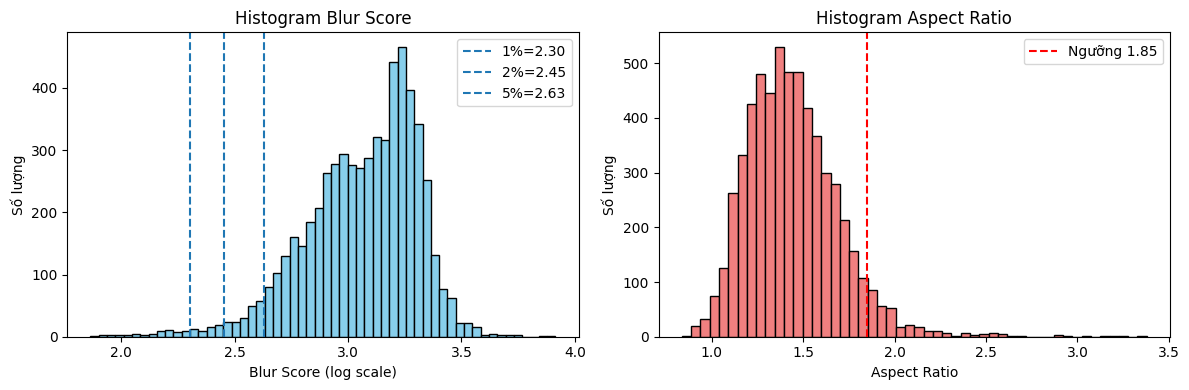

Phân vị blur_score:
count    5856.000000
mean        3.061320
std         0.246905
min         1.863880
1%          2.302484
2%          2.453044
5%          2.630423
10%         2.736056
25%         2.911353
50%         3.103106
75%         3.245202
90%         3.329854
max         3.914328
Name: blur_score, dtype: float64


In [15]:
# Cell 3: Histogram của blur_score và aspect_ratio
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['blur_score'].dropna(), bins='auto', color='skyblue', edgecolor='black')
plt.title('Histogram Blur Score')
plt.xlabel('Blur Score (log scale)')
plt.ylabel('Số lượng')
quantiles = [0.01, 0.02, 0.05]
for q in quantiles:
    threshold = df['blur_score'].quantile(q)
    plt.axvline(threshold, linestyle='--', label=f'{int(q*100)}%={threshold:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df['aspect_ratio'].dropna(), bins=50, color='lightcoral', edgecolor='black')
plt.title('Histogram Aspect Ratio')
plt.xlabel('Aspect Ratio')
plt.ylabel('Số lượng')
plt.axvline(1.85, linestyle='--', color='red', label='Ngưỡng 1.85')
plt.legend()

plt.tight_layout()
plt.show()

print("Phân vị blur_score:")
print(df['blur_score'].describe(percentiles=[0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9]))

Số ảnh tốt dùng để khảo sát hash: 5352
Đang tính pHash cho 3000 ảnh mẫu...
Đang tính khoảng cách pairwise...
  Đã xử lý 0/3000
  Đã xử lý 500/3000
  Đã xử lý 1000/3000
  Đã xử lý 1500/3000
  Đã xử lý 2000/3000
  Đã xử lý 2500/3000
Hoàn thành tính khoảng cách.

>>> Ngưỡng Hamming đề xuất (phân vị 1%): 86


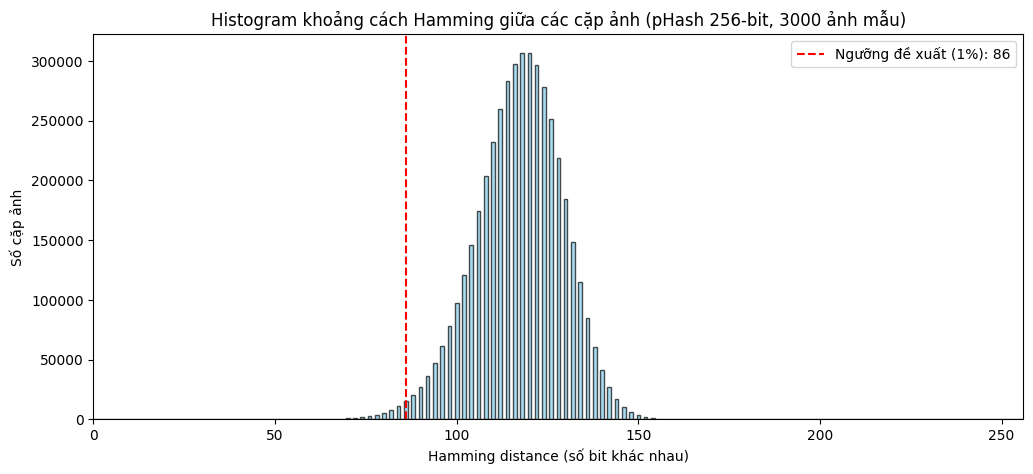


Phân vị của khoảng cách Hamming (tham khảo):
  0.1% số cặp có distance ≤ 74.0
  0.5% số cặp có distance ≤ 82.0
  1% số cặp có distance ≤ 86.0
  2% số cặp có distance ≤ 90.0
  5% số cặp có distance ≤ 96.0


In [16]:
# Cell 4: Khảo sát histogram khoảng cách Hamming (ĐÃ SỬA LỖI PERCENTILE)
# Lấy mẫu từ các ảnh tốt (aspect_ratio < 1.85 và blur_score > quantile 0.05)
ASPECT_RATIO_THRESHOLD = 1.85
BLUR_THRESHOLD = df['blur_score'].quantile(0.05)

df_good_for_hash = df[(df['aspect_ratio'] < ASPECT_RATIO_THRESHOLD) & (df['blur_score'] > BLUR_THRESHOLD)].copy()
print(f"Số ảnh tốt dùng để khảo sát hash: {len(df_good_for_hash)}")

NUM_SAMPLES = min(3000, len(df_good_for_hash))
sampled_df = df_good_for_hash.sample(n=NUM_SAMPLES, random_state=42)
paths = sampled_df['path'].tolist()

print(f"Đang tính pHash cho {len(paths)} ảnh mẫu...")

HASH_SIZE = 16
BITS = HASH_SIZE * HASH_SIZE

bit_array = []
for p in paths:
    h = imagehash.phash(Image.open(p), hash_size=HASH_SIZE)
    int_val = int(str(h), 16)
    bits = np.array([(int_val >> i) & 1 for i in range(BITS - 1, -1, -1)], dtype=np.uint8)
    bit_array.append(bits)
bit_array = np.array(bit_array)

# Tính pairwise Hamming distance
n = bit_array.shape[0]
hist = np.zeros(BITS + 1, dtype=np.int64)
print("Đang tính khoảng cách pairwise...")
for i in range(n):
    if i % 500 == 0:
        print(f"  Đã xử lý {i}/{n}")
    if i < n - 1:
        diff = np.count_nonzero(bit_array[i] != bit_array[i + 1:], axis=1)
        np.add.at(hist, diff, 1)

print("Hoàn thành tính khoảng cách.")

# Tạo mảng dữ liệu để tính phân vị
all_distances = np.repeat(np.arange(BITS + 1), hist)

# -----------------------------------------
# VẼ HISTOGRAM
# -----------------------------------------
plt.figure(figsize=(12, 5))
bins = np.arange(BITS + 2) - 0.5
plt.hist(all_distances, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Hamming distance (số bit khác nhau)')
plt.ylabel('Số cặp ảnh')
plt.title(f'Histogram khoảng cách Hamming giữa các cặp ảnh (pHash {BITS}-bit, {n} ảnh mẫu)')
plt.xlim(0, BITS)

# -----------------------------------------
# CHỌN THRESHOLD DỰA TRÊN PHÂN VỊ 1% (ĐÃ SỬA LỖI LABEL)
# -----------------------------------------
THRESHOLD_PERCENTILE = 1  # Đây là 1% (giá trị từ 0 đến 100)
hamming_threshold = int(np.percentile(all_distances, THRESHOLD_PERCENTILE))
print(f"\n>>> Ngưỡng Hamming đề xuất (phân vị {THRESHOLD_PERCENTILE}%): {hamming_threshold}")

# Vẽ đường ngưỡng lên biểu đồ
plt.axvline(hamming_threshold, color='red', linestyle='--', 
            label=f'Ngưỡng đề xuất ({THRESHOLD_PERCENTILE}%): {hamming_threshold}')
plt.legend()
plt.show()

# -----------------------------------------
# IN BẢNG PHÂN VỊ CHUẨN XÁC (ĐÃ SỬA LỖI LABEL)
# -----------------------------------------
# Lưu ý: Các giá trị trong list này chính là % thực tế (không nhân với 100)
percentiles = [0.1, 0.5, 1, 2, 5]  # 0.1% ; 0.5% ; 1% ; 2% ; 5%
print("\nPhân vị của khoảng cách Hamming (tham khảo):")
for p in percentiles:
    val = np.percentile(all_distances, p)
    # Sửa: in ra chính xác p% thay vì p*100%
    print(f"  {p}% số cặp có distance ≤ {val:.1f}")

# Lưu threshold để dùng cho các cell sau
HAMMING_THRESHOLD = hamming_threshold

Đang tìm các cặp trùng lặp trên toàn bộ tập ảnh tốt (không phân biệt split)...
Tìm thấy 34 cặp trùng lặp.

=== 20 CẶP TRÙNG LẶP CÓ HAMMING DISTANCE LỚN NHẤT (GẦN NGƯỠNG) ===
                                                                                                                 path1 split1    label1    blur1                                                                                                                  path2 split2    label2    blur2  distance
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0587-0001-0001.jpeg  train    NORMAL 3.481960   /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0587-0001-0002.jpeg  train    NORMAL 3.481960         0
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1372_bacteria_3503.jpeg  train PNEUMONIA 3.014078 /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PN

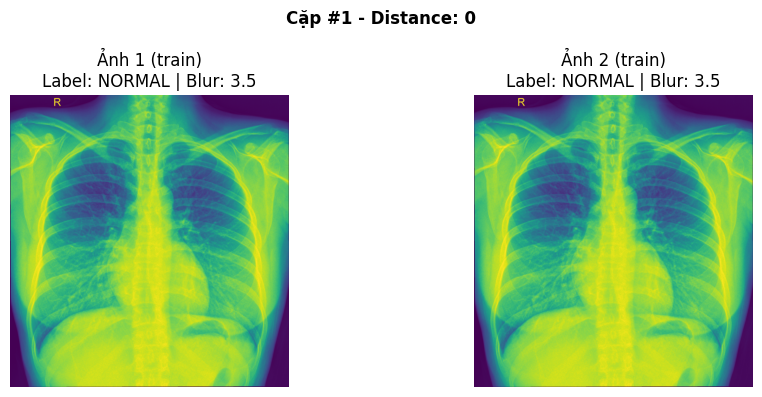

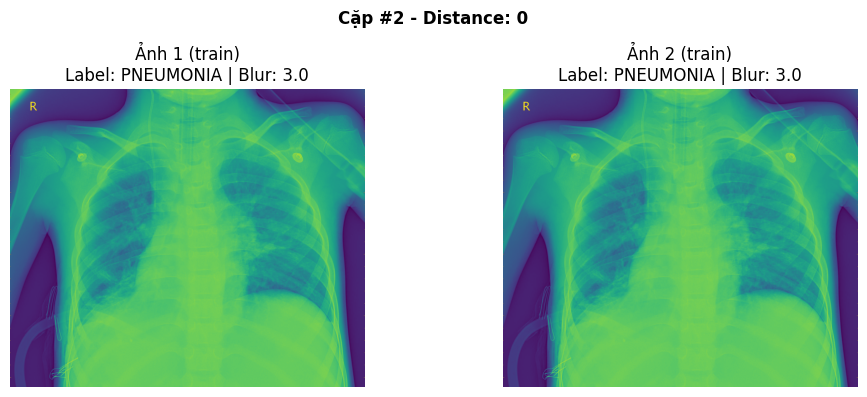

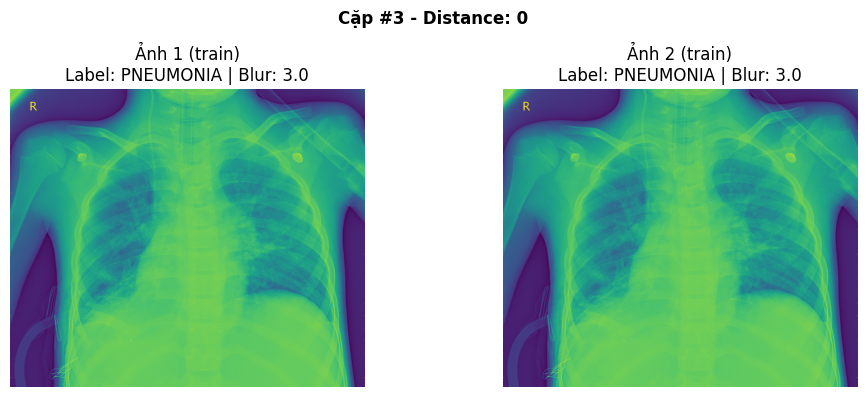

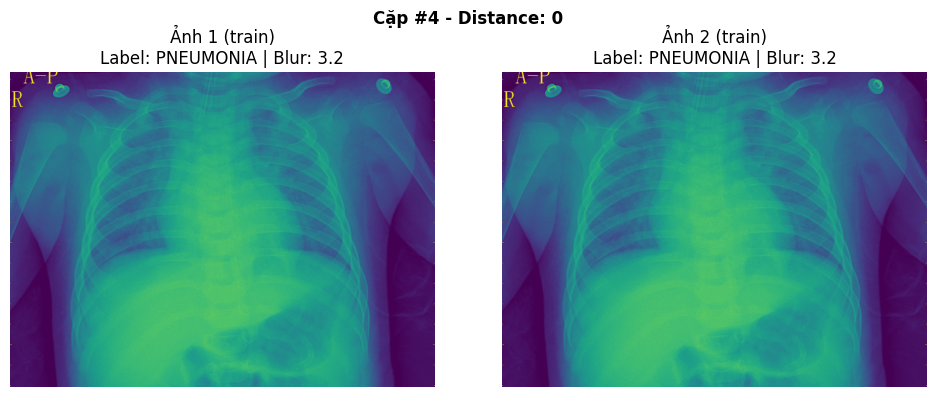

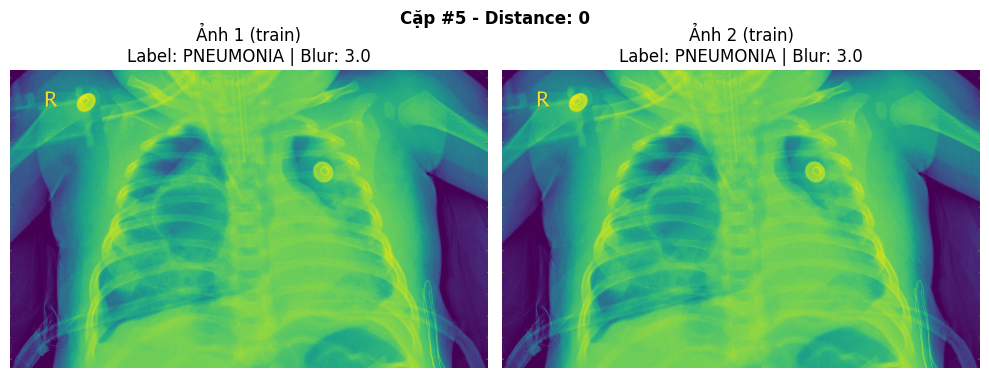

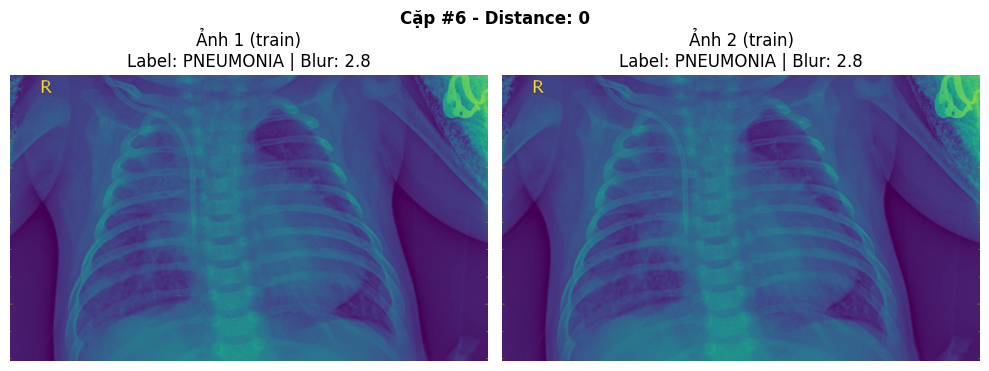

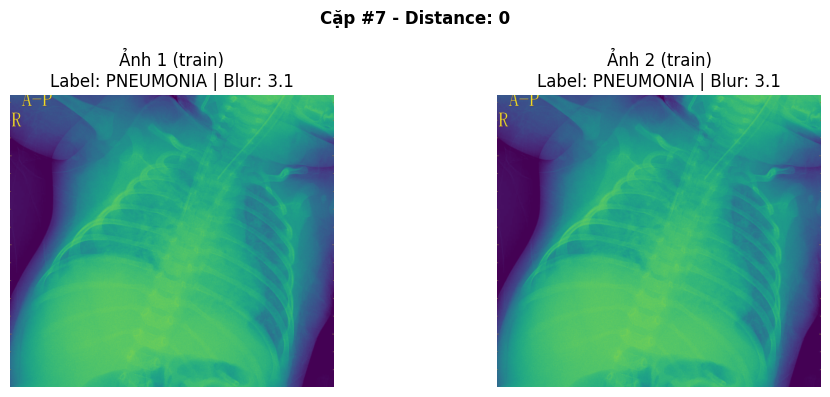

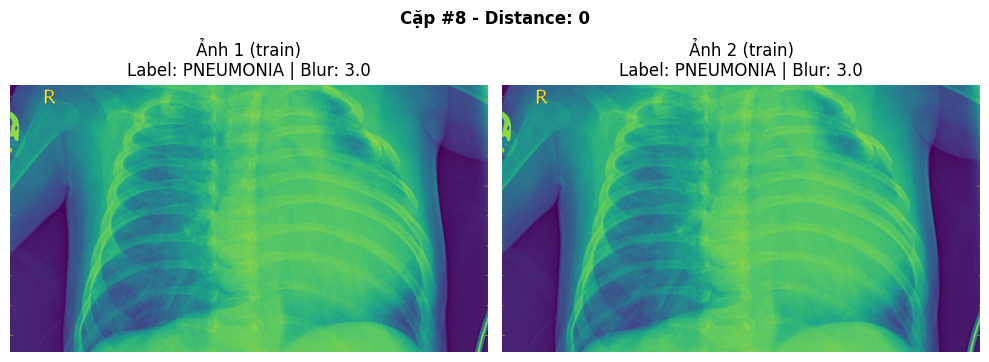

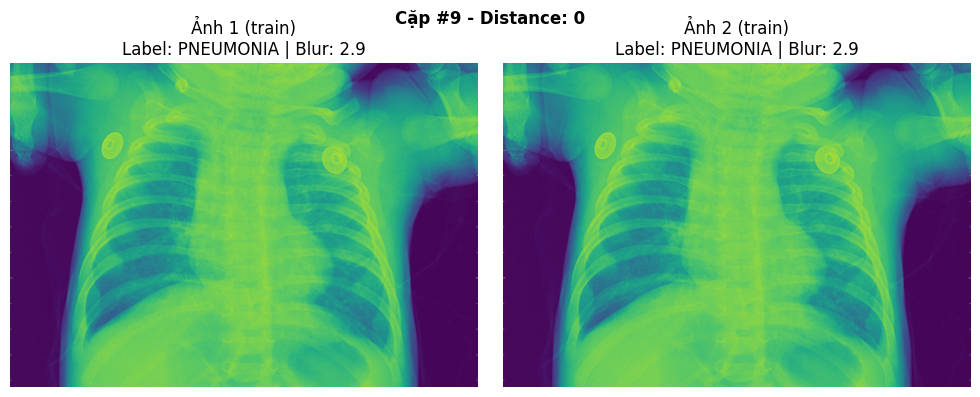

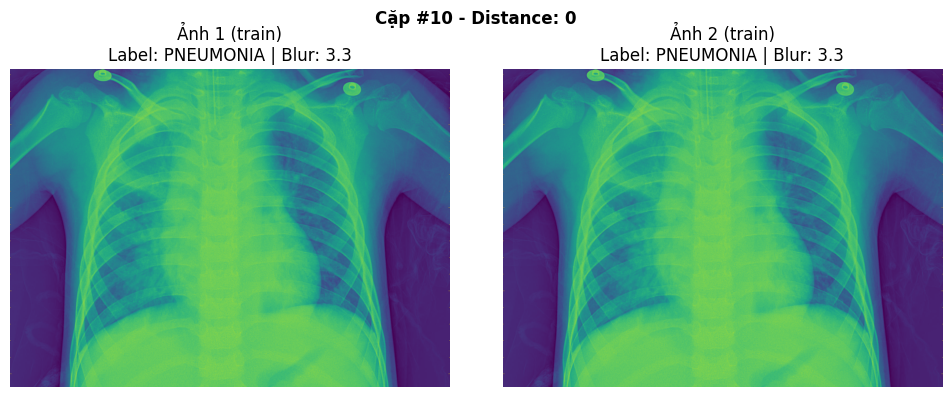

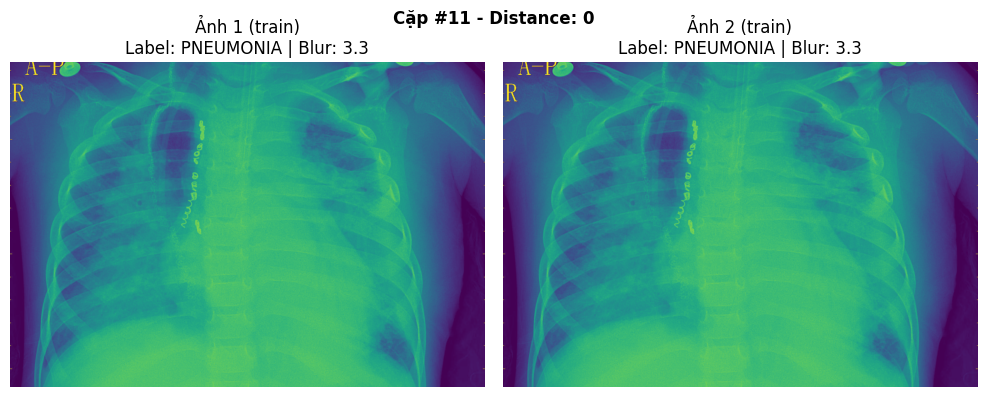

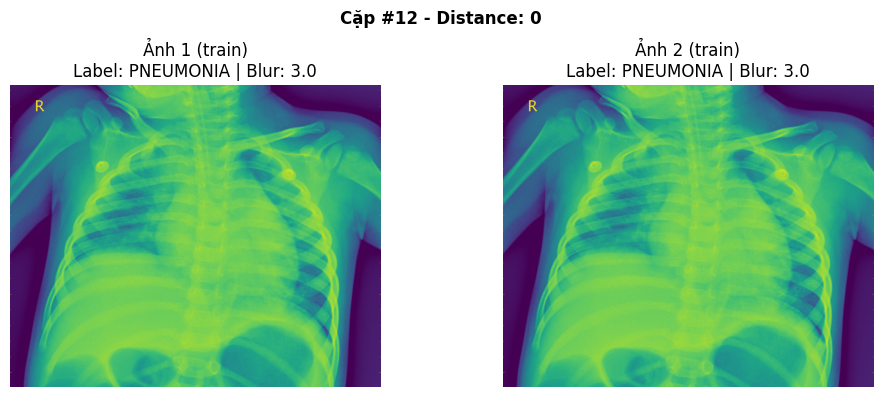

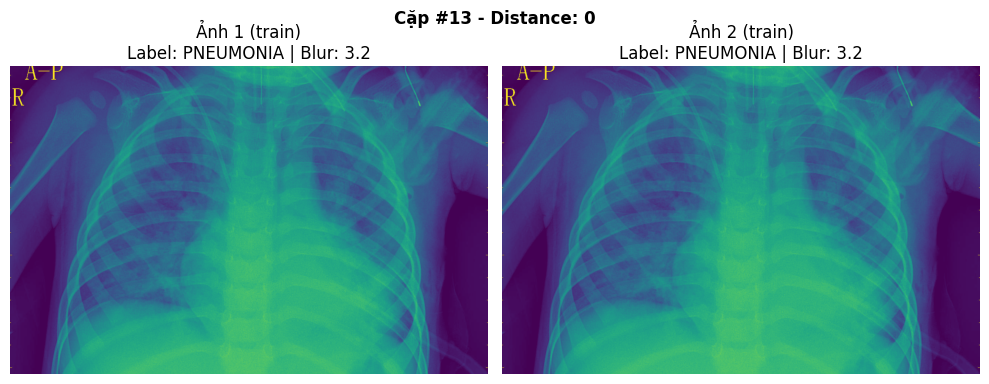

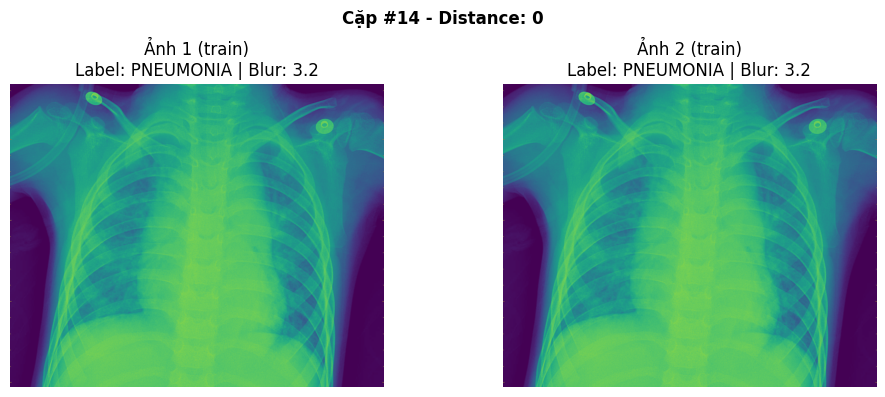

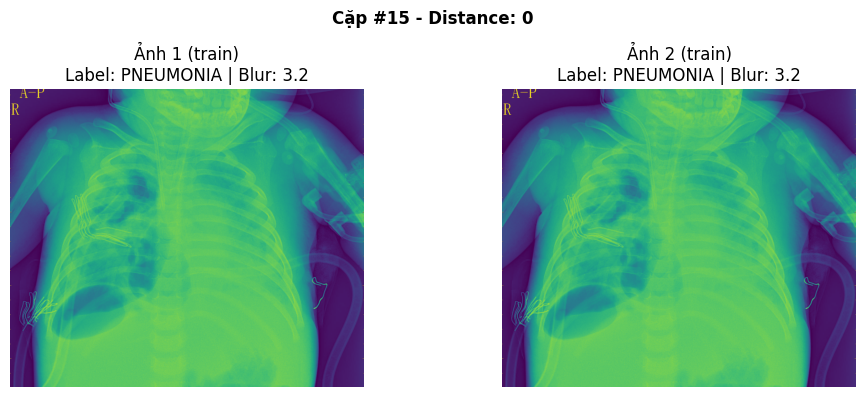

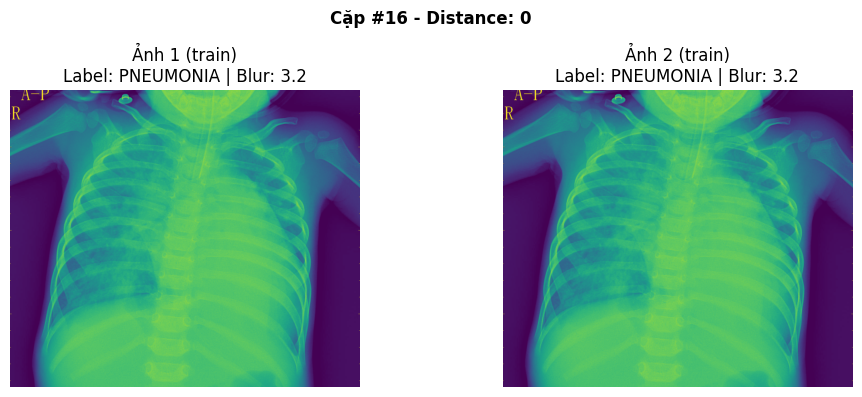

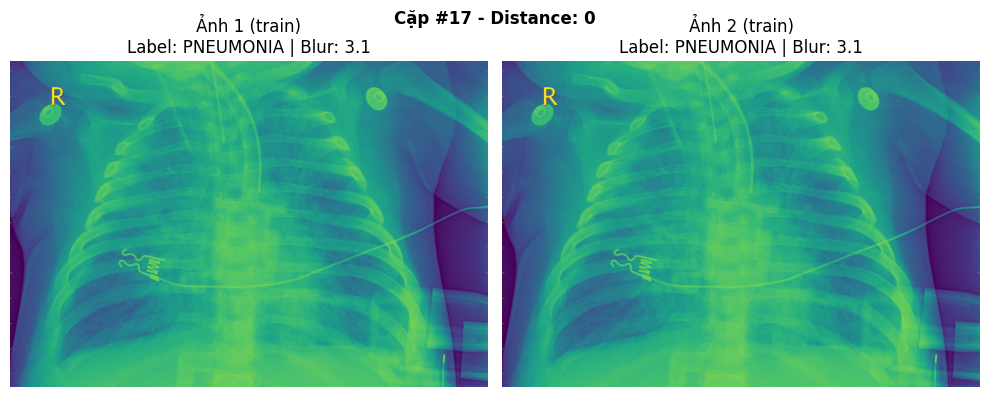

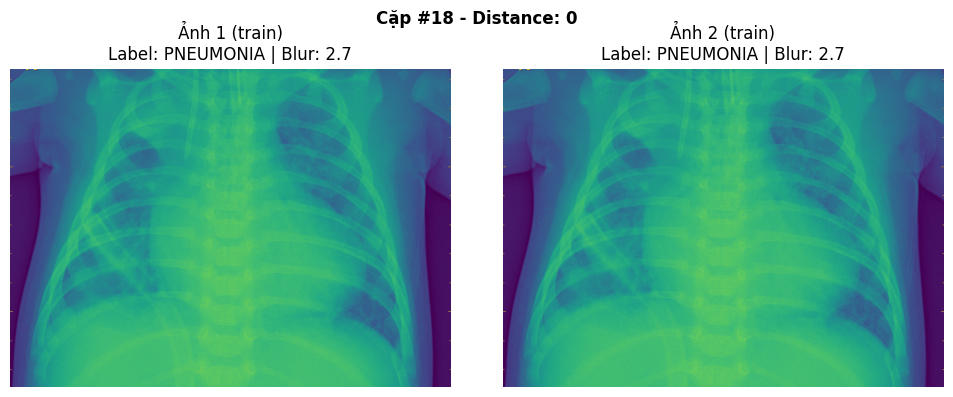

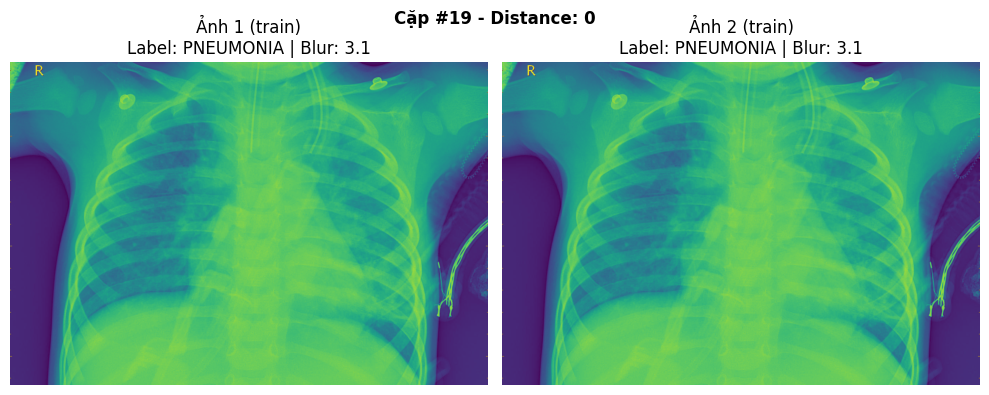

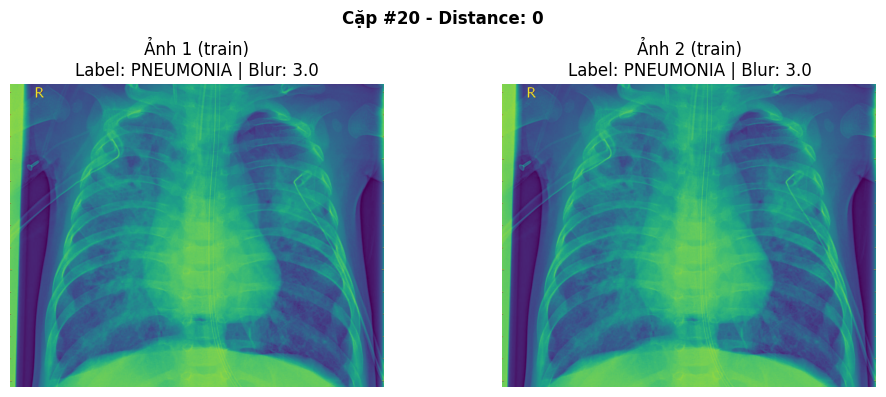


Đã lưu toàn bộ 34 cặp trùng lặp vào /kaggle/working/duplicate_pairs_all.csv

Số ảnh bị loại do trùng lặp: 32
--- THỐNG KÊ LOẠI BỎ ---
Số ảnh bị loại do aspect ratio: 321
Số ảnh bị loại do blur: 183
Số ảnh bị loại do trùng lặp: 32
Tổng số ảnh bị loại: 536 / 5856
Số ảnh tốt còn lại: 5320 / 5856

Phân bố sau khi chia lại:
label  NORMAL  PNEUMONIA
split                   
test      236        562
train    1103       2621
val       236        562

✅ Đã lưu 5320 ảnh sạch vào /kaggle/working/splits.csv


In [17]:
# ================== CELL 5: LỌC DỮ LIỆU, CHIA LẠI SPLIT & XUẤT CSV ==================
# ================== CHỈNH NGƯỠNG TẠI ĐÂY ==================
ASPECT_RATIO_THRESHOLD = 1.85
BLUR_THRESHOLD = df['blur_score'].quantile(0.05)   # Có thể thay bằng giá trị cụ thể
DUPLICATE_DISTANCE_THRESHOLD = 10                 # Ta khảo sát lại thì ngưỡng hamming distance ở histogram chỉ có giá trị tham khảo vì histogram chỉ có 1 đỉnh dẫn đến nên khảo sát ở khu vực nhỏ phía bên trái như 10, 20
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

# Khởi tạo cột đánh dấu
df['quality_issue'] = False
df['quality_reason'] = ""

# 1. Lọc aspect ratio
bad_ar_mask = df['aspect_ratio'] >= ASPECT_RATIO_THRESHOLD
df.loc[bad_ar_mask, 'quality_issue'] = True
df.loc[bad_ar_mask, 'quality_reason'] = df.loc[bad_ar_mask, 'aspect_ratio'].apply(
    lambda ar: f"Aspect ratio {ar:.2f} ≥ {ASPECT_RATIO_THRESHOLD}"
)

# 2. Lọc blur (chỉ áp dụng cho ảnh chưa bị loại bởi aspect ratio)
blur_mask = (df['blur_score'] < BLUR_THRESHOLD) & (~df['quality_issue'])
df.loc[blur_mask, 'quality_issue'] = True
df.loc[blur_mask, 'quality_reason'] = df.loc[blur_mask, 'blur_score'].apply(
    lambda bs: f"Blurred (score {bs:.2f} < {BLUR_THRESHOLD:.2f})"
)

# Lưu cột split gốc trước khi ghi đè (phục vụ việc hiển thị)
df['original_split'] = df['split']

# 3. Tạo DataFrame chỉ chứa ảnh tốt (chưa bị loại bởi AR hoặc blur)
df_good_current = df[~df['quality_issue']].copy()

# ================== TÌM CẶP TRÙNG LẶP TRÊN TOÀN BỘ ẢNH TỐT ==================
print("Đang tìm các cặp trùng lặp trên toàn bộ tập ảnh tốt (không phân biệt split)...")
duplicate_pairs = []    # (idx1, idx2, distance)

# So sánh tất cả các cặp (i < j) trong df_good_current
hashes = df_good_current['phash'].tolist()
indices = df_good_current.index.tolist()
n = len(hashes)

# Để tăng tốc, ta có thể dùng vòng lặp Python thông thường
for i in range(n):
    for j in range(i + 1, n):
        dist = hamming_distance(hashes[i], hashes[j])
        if dist <= DUPLICATE_DISTANCE_THRESHOLD:
            duplicate_pairs.append((indices[i], indices[j], dist))

print(f"Tìm thấy {len(duplicate_pairs)} cặp trùng lặp.")

# ================== HIỂN THỊ 20 CẶP CÓ DISTANCE LỚN NHẤT ==================
if duplicate_pairs:
    pairs_df = pd.DataFrame(duplicate_pairs, columns=['idx1', 'idx2', 'distance'])
    
    # Lấy thông tin cho từng ảnh
    for idx_col, prefix in [('idx1', '1'), ('idx2', '2')]:
        pairs_df[f'path{prefix}'] = df.loc[pairs_df[idx_col], 'path'].values
        pairs_df[f'label{prefix}'] = df.loc[pairs_df[idx_col], 'label'].values
        pairs_df[f'blur{prefix}'] = df.loc[pairs_df[idx_col], 'blur_score'].values
        pairs_df[f'split{prefix}'] = df.loc[pairs_df[idx_col], 'original_split'].values  # dùng split gốc
    
    # Sắp xếp theo distance giảm dần, lấy 20 cặp lớn nhất
    pairs_df_sorted = pairs_df.sort_values('distance', ascending=False).head(20)
    
    print("\n=== 20 CẶP TRÙNG LẶP CÓ HAMMING DISTANCE LỚN NHẤT (GẦN NGƯỠNG) ===")
    display_cols = ['path1', 'split1', 'label1', 'blur1',
                    'path2', 'split2', 'label2', 'blur2', 'distance']
    print(pairs_df_sorted[display_cols].to_string(index=False))
    
    # --- BỔ SUNG: VẼ TRỰC QUAN 20 CẶP ẢNH TẠI ĐÂY ---
    print("\nĐang hiển thị hình ảnh 20 cặp trùng lặp...")
    for i, (_, row) in enumerate(pairs_df_sorted.iterrows()):
        try:
            img1 = Image.open(row['path1'])
            img2 = Image.open(row['path2'])

            fig, axes = plt.subplots(1, 2, figsize=(10, 4))

            axes[0].imshow(img1)
            axes[0].set_title(f"Ảnh 1 ({row['split1']})\nLabel: {row['label1']} | Blur: {row['blur1']:.1f}")
            axes[0].axis('off')

            axes[1].imshow(img2)
            axes[1].set_title(f"Ảnh 2 ({row['split2']})\nLabel: {row['label2']} | Blur: {row['blur2']:.1f}")
            axes[1].axis('off')

            plt.suptitle(f"Cặp #{i+1} - Distance: {row['distance']}", fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
            plt.close()
        except Exception as e:
            print(f"Không thể mở ảnh ở cặp #{i+1}: {e}")

    # Lưu toàn bộ danh sách cặp trùng lặp (nếu muốn)
    pairs_df.to_csv('/kaggle/working/duplicate_pairs_all.csv', index=False)
    print(f"\nĐã lưu toàn bộ {len(duplicate_pairs)} cặp trùng lặp vào /kaggle/working/duplicate_pairs_all.csv")
else:
    print("Không tìm thấy cặp trùng lặp nào.")

# ================== LOẠI BỎ ẢNH TRÙNG LẶP ==================
# Xác định các ảnh cần loại: với mỗi cặp, loại ảnh có blur_score thấp hơn
# Sắp xếp các cặp theo distance tăng dần (ưu tiên xử lý cặp gần nhất trước)
duplicate_pairs_sorted = sorted(duplicate_pairs, key=lambda x: x[2])

to_remove = set()
for idx1, idx2, dist in duplicate_pairs_sorted:
    if idx1 in to_remove or idx2 in to_remove:
        continue  # một trong hai đã bị loại bởi cặp trước đó
    # So sánh blur_score
    blur1 = df.loc[idx1, 'blur_score']
    blur2 = df.loc[idx2, 'blur_score']
    if np.isnan(blur1):
        blur1 = -np.inf
    if np.isnan(blur2):
        blur2 = -np.inf
    if blur1 >= blur2:
        to_remove.add(idx2)
    else:
        to_remove.add(idx1)

# Đánh dấu vào df
duplicate_mask = df.index.isin(to_remove) & (~df['quality_issue'])
df.loc[duplicate_mask, 'quality_issue'] = True
df.loc[duplicate_mask, 'quality_reason'] = "Duplicate (tương đồng với ảnh khác)"

print(f"\nSố ảnh bị loại do trùng lặp: {duplicate_mask.sum()}")

# ================== THỐNG KÊ CUỐI CÙNG ==================
print(f"--- THỐNG KÊ LOẠI BỎ ---")
print(f"Số ảnh bị loại do aspect ratio: {bad_ar_mask.sum()}")
print(f"Số ảnh bị loại do blur: {blur_mask.sum()}")
print(f"Số ảnh bị loại do trùng lặp: {duplicate_mask.sum()}")
print(f"Tổng số ảnh bị loại: {df['quality_issue'].sum()} / {len(df)}")
print(f"Số ảnh tốt còn lại: {(~df['quality_issue']).sum()} / {len(df)}")

# ================== CHIA LẠI TRAIN / VAL / TEST ==================
# Tạo DataFrame sạch
df_clean = df[~df['quality_issue']].copy()

# Tỷ lệ chia: Train 70%, Val 15%, Test 15% (stratified theo label)
X = df_clean.index.values
y = df_clean['label'].values

# Bước 1: Tách test (15%) từ toàn bộ
train_val_idx, test_idx = train_test_split(
    X, test_size=0.15, random_state=42, stratify=y
)

# Bước 2: Tách val (15% của toàn bộ) từ train_val
# Trong train_val hiện có 85% dữ liệu, muốn val chiếm 15% tổng => val chiếm 15/85 = 0.17647 của train_val
train_val_labels = df_clean.loc[train_val_idx, 'label'].values
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.15 / 0.85,   # tương đương 15% tổng
    random_state=42,
    stratify=train_val_labels
)

# Gán split mới
df_clean['split_new'] = 'train'
df_clean.loc[val_idx, 'split_new'] = 'val'
df_clean.loc[test_idx, 'split_new'] = 'test'

# Cập nhật cột 'split' chính thức
df_clean['split'] = df_clean['split_new']
df_clean = df_clean.drop(columns=['split_new'])

# Kiểm tra phân bố
print("\nPhân bố sau khi chia lại:")
pivot = df_clean.pivot_table(index='split', columns='label', values='path', aggfunc='count', fill_value=0)
print(pivot)

# ================== LƯU FILE CSV CUỐI CÙNG ==================
cols_to_save = ['path', 'split', 'label', 'aspect_ratio', 'blur_score', 'phash']
df_clean[cols_to_save].to_csv('/kaggle/working/splits.csv', index=False)
print(f"\n✅ Đã lưu {len(df_clean)} ảnh sạch vào /kaggle/working/splits.csv")